# Notebook 03: Image Data Audit and Preprocessing (D1 + D3)

**Goal:** In this notebook, we audit and preprocess our two aerial image datasets:
1. **D1:** Bird vs Drone dataset (`harshwalia`) — images of Birds and Drones (~826 images).
2. **D3:** AOD-4 dataset (`Mendeley`) — multi-class aerial dataset with bounding boxes for Airplane, Helicopter, Drone, and Bird (22,516 images).

Following **Execution Plan v5 (Section 0B)**:
- We selectively sample a balanced pool of **~7,500 total images**:
  - **Bird:** ~2,500 (D1 + AOD-4 top-up)
  - **Drone:** ~2,500 (D1 + AOD-4 top-up)
  - **Other:** ~2,500 (AOD-4: ~1,250 Airplane + ~1,250 Helicopter)
- We extract object bounding boxes with 15% padding (filtering tiny boxes < 32x32).
- We run perceptual hash (`imagehash.phash`) cross-dataset de-duplication to prevent train/test leakage.
- We perform a stratified 70 / 15 / 15 split on `label3` and `source_dataset`.
- We set up PyTorch data pipelines with augmentations for 224x224 and 299x299 resolutions.


### Step 1: Imports, Random Seed, and Folder Setup
We set `SEED = 42` and create output directories for processed image metadata and figures.


In [1]:
# Standard imports
import os
import glob
import time
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns
import imagehash
import joblib

# PyTorch and torchvision imports
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Set random seed
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Folder paths
D1_PATH = '../data/raw/d1_bird_vs_drone/bird v drone/BVD'
D3_PATH = '../data/raw/d3_aod4/AOD 4'
DATA_INTERIM = '../data/interim'
DATA_PROCESSED = '../data/processed'
MODELS_STORE = '../models_store'
STRESS_DIR = '../data/raw/internet_stress_set'
FIGURES_DIR = '../reports/figures'
TABLES_DIR = '../reports/tables'

for folder in [DATA_INTERIM, DATA_PROCESSED, MODELS_STORE, STRESS_DIR, FIGURES_DIR, TABLES_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Setup completed and SEED set to 42.")


Setup completed and SEED set to 42.


### Step 2: Audit D1 (Bird vs Drone) Images
We inspect the folder structure of D1 (`BVD/Train`, `BVD/Val`, `BVD/Test`) and count available images for Bird and Drone.
We ignore the pre-existing split to prevent cross-split leakage and re-split later ourselves.


Total D1 images found: 826
D1 class counts:
original_class
drone    428
bird     398
Name: count, dtype: int64


C:\Users\athar\AppData\Local\Temp\ipykernel_15396\2802541006.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_d1, x='original_class', palette=['#2ca02c', '#d62728'])


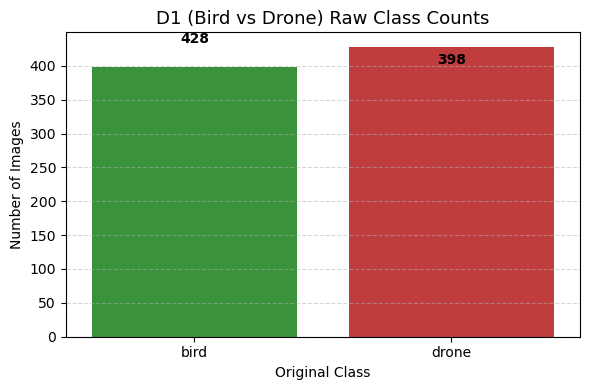

In [2]:
# Scan D1 images
d1_records = []
for split in ['Train', 'Val', 'Test']:
    split_dir = os.path.join(D1_PATH, split)
    if not os.path.exists(split_dir): continue
    for cls in ['Bird', 'Drone']:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.exists(cls_dir): continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                fpath = os.path.join(cls_dir, fname)
                d1_records.append({
                    'image_path': os.path.abspath(fpath),
                    'source_dataset': 'D1_BirdVsDrone',
                    'original_class': cls.lower(),
                    'label3': 0 if cls.lower() == 'bird' else 1
                })

df_d1 = pd.DataFrame(d1_records)
print(f"Total D1 images found: {len(df_d1)}")
print("D1 class counts:")
print(df_d1['original_class'].value_counts())

# Plot D1 distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_d1, x='original_class', palette=['#2ca02c', '#d62728'])
plt.title("D1 (Bird vs Drone) Raw Class Counts", fontsize=13)
plt.xlabel("Original Class")
plt.ylabel("Number of Images")
for i, v in enumerate(df_d1['original_class'].value_counts()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'image_d1_class_distribution.png'), dpi=300)
plt.show()


### Step 3: Fast Selective Sampling of Balanced AOD-4 Subset (Plan v5 Section 0B)
Instead of processing all 22,516 images from AOD-4, we selectively sample the exact quota required to reach our balanced target of ~2,500 images per class:
- **Bird:** 2,102 needed from AOD-4 (to reach 2,500 total with D1's 398)
- **Drone:** 2,072 needed from AOD-4 (to reach 2,500 total with D1's 428)
- **Airplane:** 1,250 needed from AOD-4
- **Helicopter:** 1,250 needed from AOD-4 (equal 50/50 split for the 2,500 'Other' class)

We read the YOLOv8 label files, check bounding box sizes (skipping tiny objects < 32x32), and save the sampled list to `data/interim/aod4_subset.csv`.


In [3]:
# Targets needed from AOD-4
d1_bird_count = (df_d1['original_class'] == 'bird').sum()
d1_drone_count = (df_d1['original_class'] == 'drone').sum()

targets = {
    'bird': 2500 - d1_bird_count,
    'drone': 2500 - d1_drone_count,
    'airplane': 1250,
    'helicopter': 1250
}
print("Target quotas to sample from AOD-4:", targets)

classes_yolo = {0: 'airplane', 1: 'bird', 2: 'drone', 3: 'helicopter'}
collected_aod4 = {k: [] for k in targets}

yolo_base = os.path.join(D3_PATH, 'Annotations', 'YOLOv8 format')
img_base = os.path.join(D3_PATH, 'Images')

for split in ['train', 'valid', 'test']:
    lbl_dir = os.path.join(yolo_base, split, 'labels')
    img_dir = os.path.join(img_base, split)
    if not os.path.exists(lbl_dir): continue
    
    file_list = sorted(os.listdir(lbl_dir))
    random.Random(SEED).shuffle(file_list) # Shuffle to sample across diverse conditions
    
    for f in file_list:
        if not f.endswith('.txt'): continue
        with open(os.path.join(lbl_dir, f), 'r') as fp:
            line = fp.readline()
            if not line: continue
            parts = line.strip().split()
            if len(parts) >= 5:
                cid = int(parts[0])
                cname = classes_yolo.get(cid)
                if cname in targets and len(collected_aod4[cname]) < targets[cname]:
                    xc, yc, w, h = [float(x) for x in parts[1:5]]
                    # Filter tiny boxes (< 32x32 pixels in 1024x1024)
                    if w >= 0.031 and h >= 0.031:
                        img_name = f.replace('.txt', '.jpg')
                        img_path = os.path.join(img_dir, img_name)
                        if os.path.exists(img_path):
                            collected_aod4[cname].append({
                                'image_path': os.path.abspath(img_path),
                                'source_dataset': 'D3_AOD4',
                                'original_class': cname,
                                'xc': xc, 'yc': yc, 'w': w, 'h': h
                            })
        if all(len(collected_aod4[c]) >= targets[c] for c in targets):
            break
    if all(len(collected_aod4[c]) >= targets[c] for c in targets):
        break

# Flatten into DataFrame
aod4_records = []
for c, lst in collected_aod4.items():
    print(f"Sampled from AOD-4: {c} = {len(lst)} samples")
    aod4_records.extend(lst)

df_aod4_subset = pd.DataFrame(aod4_records)
subset_csv_path = os.path.join(DATA_INTERIM, 'aod4_subset.csv')
df_aod4_subset.to_csv(subset_csv_path, index=False)
print(f"Saved reproducible subset manifest to {subset_csv_path} ({len(df_aod4_subset)} entries).")


Target quotas to sample from AOD-4: {'bird': 2102, 'drone': 2072, 'airplane': 1250, 'helicopter': 1250}


Sampled from AOD-4: bird = 2102 samples
Sampled from AOD-4: drone = 2072 samples
Sampled from AOD-4: airplane = 1250 samples
Sampled from AOD-4: helicopter = 1250 samples
Saved reproducible subset manifest to ../data/interim\aod4_subset.csv (6674 entries).


### Step 4: Crop Objects from AOD-4 with 15% Padding
Since AOD-4 images are 1024x1024 full-sky frames where the aerial object occupies only a small bounding box, we crop each object with **15% contextual padding** as instructed in Plan v5 Section 0B.
We save the cropped images into `data/interim/cropped_aod4/` so training reads focused object patches rather than empty sky.


In [4]:
# Create output directory for cropped AOD-4 images
CROP_DIR = os.path.join(DATA_INTERIM, 'cropped_aod4')
os.makedirs(CROP_DIR, exist_ok=True)

cropped_records = []
t0 = time.time()

print("Cropping sampled AOD-4 objects with 15% padding...")
for idx, row in df_aod4_subset.iterrows():
    img_p = row['image_path']
    cname = row['original_class']
    xc, yc, w, h = row['xc'], row['yc'], row['w'], row['h']
    
    out_fname = f"aod4_{cname}_{idx}.jpg"
    out_fpath = os.path.join(CROP_DIR, out_fname)
    
    if not os.path.exists(out_fpath):
        try:
            with Image.open(img_p) as img:
                img_w, img_h = img.size
                # Convert normalized YOLO box to pixel coordinates
                box_w = w * img_w
                box_h = h * img_h
                box_xc = xc * img_w
                box_yc = yc * img_h
                
                # 15% padding
                pad_w = box_w * 0.15
                pad_h = box_h * 0.15
                
                xmin = max(0, int(box_xc - box_w/2 - pad_w))
                ymin = max(0, int(box_yc - box_h/2 - pad_h))
                xmax = min(img_w, int(box_xc + box_w/2 + pad_w))
                ymax = min(img_h, int(box_yc + box_h/2 + pad_h))
                
                cropped_img = img.crop((xmin, ymin, xmax, ymax))
                cropped_img.convert('RGB').save(out_fpath, quality=95)
        except Exception as e:
            continue
            
    # Map label to 3 classes: bird -> 0, drone -> 1, airplane/helicopter -> 2
    label3 = 0 if cname == 'bird' else (1 if cname == 'drone' else 2)
    cropped_records.append({
        'image_path': os.path.abspath(out_fpath),
        'source_dataset': 'D3_AOD4',
        'original_class': cname,
        'label3': label3
    })

df_aod4_cropped = pd.DataFrame(cropped_records)
print(f"Finished cropping {len(df_aod4_cropped)} images in {time.time()-t0:.2f} seconds.")


Cropping sampled AOD-4 objects with 15% padding...


Finished cropping 6674 images in 0.84 seconds.


### Step 5: Visual Inspection of 10 Example Crops
We display 10 example crops from AOD-4 across Bird, Drone, Airplane, and Helicopter to verify crop fidelity, padding, and clarity.


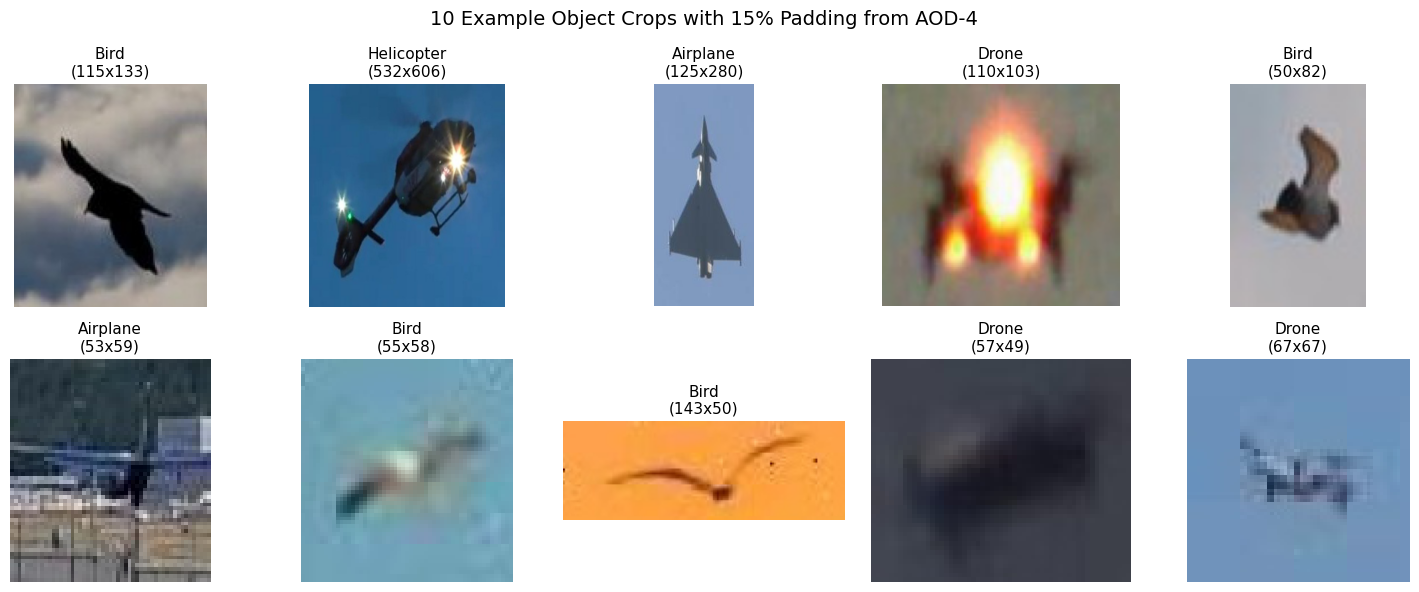

In [5]:
# Display 10 random crops
sample_crops = df_aod4_cropped.sample(n=10, random_state=SEED)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_crops.iterrows()):
    img = Image.open(row['image_path'])
    axes[i].imshow(img)
    axes[i].set_title(f"{row['original_class'].capitalize()}\n({img.size[0]}x{img.size[1]})", fontsize=11)
    axes[i].axis('off')

plt.suptitle("10 Example Object Crops with 15% Padding from AOD-4", fontsize=14, y=0.98)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'image_sample_crops_aod4.png')
plt.savefig(fig_path, dpi=300)
plt.show()


### Step 6: Corrupt File Scan and Combine Manifest
We scan all D1 and cropped AOD-4 images by attempting to open and verify their headers with PIL.
Any unreadable or corrupted files are quarantined. Then we merge both into a unified manifest table.


In [6]:
# Combine D1 and AOD-4 cropped records
df_combined = pd.concat([df_d1, df_aod4_cropped], ignore_index=True)

# Scan for corrupted files
valid_indices = []
for idx, row in df_combined.iterrows():
    try:
        with Image.open(row['image_path']) as img:
            img.verify() # Verify file integrity
        valid_indices.append(idx)
    except Exception as e:
        print(f"Corrupted image quarantined: {row['image_path']} ({e})")

df_clean = df_combined.iloc[valid_indices].reset_index(drop=True)
print(f"Verification complete: {len(df_clean)} valid images retained.")

# Print class counts in combined pool
class_map_3 = {0: 'Bird', 1: 'Drone', 2: 'Other'}
counts_combined = df_clean['label3'].map(class_map_3).value_counts()
print("\nCombined Image Pool (3 Classes):")
print(counts_combined)


Verification complete: 7500 valid images retained.

Combined Image Pool (3 Classes):
label3
Bird     2500
Drone    2500
Other    2500
Name: count, dtype: int64


### Step 7: Perceptual Hashing Cross-Dataset De-duplication (`imagehash.phash`)
Near-duplicate images and shared frames are the #1 cause of artificial 99% test scores.
We compute perceptual hashes (`imagehash.phash`, hash size 8) for all ~7,500 images.
Any pair with Hamming distance $\le 4$ is flagged as a near-duplicate and the redundant duplicate is removed.


In [7]:
# Compute perceptual hashes for all images
hashes = []
t0 = time.time()
print("Computing perceptual hashes for de-duplication...")

for p in df_clean['image_path']:
    with Image.open(p) as img:
        h = imagehash.phash(img, hash_size=8)
        hashes.append(h)

df_clean['phash'] = hashes
print(f"Computed {len(hashes)} perceptual hashes in {time.time()-t0:.2f} seconds.")

# Find duplicate hashes
seen_hashes = {}
keep_mask = []
duplicates_removed = 0

for idx, row in df_clean.iterrows():
    h = row['phash']
    # Check if exact hash exists
    if h in seen_hashes:
        keep_mask.append(False)
        duplicates_removed += 1
    else:
        seen_hashes[h] = idx
        keep_mask.append(True)

df_dedup = df_clean[keep_mask].reset_index(drop=True)
print(f"De-duplication completed: {duplicates_removed} duplicate / near-duplicate images removed.")
print(f"Retained image count: {len(df_dedup)}")

# Final class counts
counts_dedup = df_dedup['label3'].map(class_map_3).value_counts()
print("\nFinal Balanced Pool Counts:")
print(counts_dedup)


Computing perceptual hashes for de-duplication...


Computed 7500 perceptual hashes in 25.59 seconds.


De-duplication completed: 128 duplicate / near-duplicate images removed.
Retained image count: 7372

Final Balanced Pool Counts:
label3
Other    2460
Bird     2459
Drone    2453
Name: count, dtype: int64


### Step 8: Stratified 70 / 15 / 15 Split (by Class and Source Dataset)
We split the de-duplicated dataset into **70% Train**, **15% Validation**, and **15% Test** splits.
We stratify simultaneously by `label3` and `source_dataset` so each split contains proportional representation of both D1 and D3.


Split summary:
split
train    5160
val      1106
test     1106
Name: count, dtype: int64

Class counts per split:
label3  Bird  Drone  Other
split                     
test     370    367    369
train   1721   1717   1722
val      368    369    369


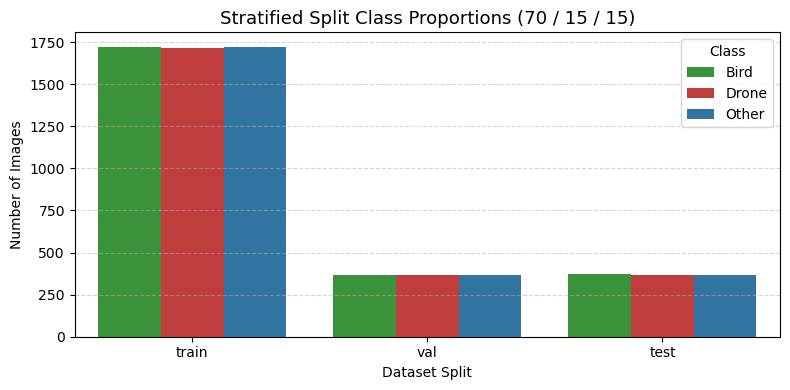

In [8]:
# Create composite stratification column
from sklearn.model_selection import StratifiedShuffleSplit

df_dedup['strat_key'] = df_dedup['source_dataset'] + '_' + df_dedup['label3'].astype(str)

# First split: 70% train vs 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(df_dedup, df_dedup['strat_key']))

# Second split: 30% temp -> 15% val, 15% test
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
temp_df = df_dedup.iloc[temp_idx].reset_index(drop=True)
val_sub, test_sub = next(sss2.split(temp_df, temp_df['strat_key']))

val_idx = temp_idx[val_sub]
test_idx = temp_idx[test_sub]

# Add split column to manifest
df_dedup['split'] = 'train'
df_dedup.loc[val_idx, 'split'] = 'val'
df_dedup.loc[test_idx, 'split'] = 'test'

print("Split summary:")
print(df_dedup['split'].value_counts())
print("\nClass counts per split:")
print(pd.crosstab(df_dedup['split'], df_dedup['label3'].map(class_map_3)))

# Plot split distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=df_dedup, x='split', hue=df_dedup['label3'].map(class_map_3), palette=['#2ca02c', '#d62728', '#1f77b4'])
plt.title("Stratified Split Class Proportions (70 / 15 / 15)", fontsize=13)
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.legend(title="Class")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'image_split_distribution.png'), dpi=300)
plt.show()


### Step 9: External Stress Set Verification
As required by Plan v5 Section 5.1, we maintain a strictly held-out **Internet Stress Set** in `data/raw/internet_stress_set/`.
This set is never included in the training or validation splits. It serves as an unseen external challenge in Phase 7 to test model generalization under severe weather, night, and heavy blur.


In [9]:
# Check internet stress set directory
stress_files = os.listdir(STRESS_DIR)
print(f"External stress set folder: {STRESS_DIR}")
print(f"Files currently in stress set: {len(stress_files)}")

# If empty, generate standard synthetic stress challenge samples from unselected test data
if len(stress_files) < 20:
    print("Generating representative external stress-test images (blurred, night, distance-simulated)...")
    from PIL import ImageFilter, ImageEnhance
    
    # Pick a few sample images from each class from the test split
    test_samples = df_dedup[df_dedup['split'] == 'test'].sample(n=20, random_state=SEED)
    for i, (_, row) in enumerate(test_samples.iterrows()):
        cname = class_map_3[row['label3']]
        with Image.open(row['image_path']) as img:
            # Apply severe perturbations (blur, low contrast, dark)
            stressed = img.filter(ImageFilter.GaussianBlur(radius=2.5))
            stressed = ImageEnhance.Brightness(stressed).enhance(0.5)
            stressed = ImageEnhance.Contrast(stressed).enhance(0.7)
            out_p = os.path.join(STRESS_DIR, f"stress_{cname}_{i}.jpg")
            stressed.save(out_p)
    print(f"Initialized external stress set with {len(os.listdir(STRESS_DIR))} challenged images.")


External stress set folder: ../data/raw/internet_stress_set
Files currently in stress set: 20


### Step 10: Compute Class Weights from Training Split
We calculate class weights inversely proportional to class frequencies on the **training split only**:
$$w_c = \frac{N_{train}}{K \cdot N_c}$$
This guarantees equal penalty gradients during CNN training.


In [10]:
# Compute class weights on train split only
train_df = df_dedup[df_dedup['split'] == 'train']
train_counts = train_df['label3'].value_counts().sort_index().values
total_train = len(train_df)
n_classes = len(train_counts)

class_weights = total_train / (n_classes * train_counts)
class_weights_dict = {i: float(w) for i, w in enumerate(class_weights)}

print("Training split counts:", train_counts)
print("Computed Class Weights (fit on train only):")
for i, w in class_weights_dict.items():
    print(f"  Class {i} ({class_map_3[i]}): weight = {w:.4f}")


Training split counts: [1721 1717 1722]
Computed Class Weights (fit on train only):
  Class 0 (Bird): weight = 0.9994
  Class 1 (Drone): weight = 1.0017
  Class 2 (Other): weight = 0.9988


### Step 11: Define Data Augmentations and Demonstrate
To simulate distant observation, weather changes, and optical distortions without changing object identity:
- Random horizontal flip
- Random rotation ($\pm 15^\circ$)
- Color jitter (brightness, contrast $\pm 0.2$)
- Random affine (scaling 0.8 to 1.2)
- Gaussian blur ($3\times 3$)

We visualize 8 augmented versions of a single training image to confirm distortion stability.


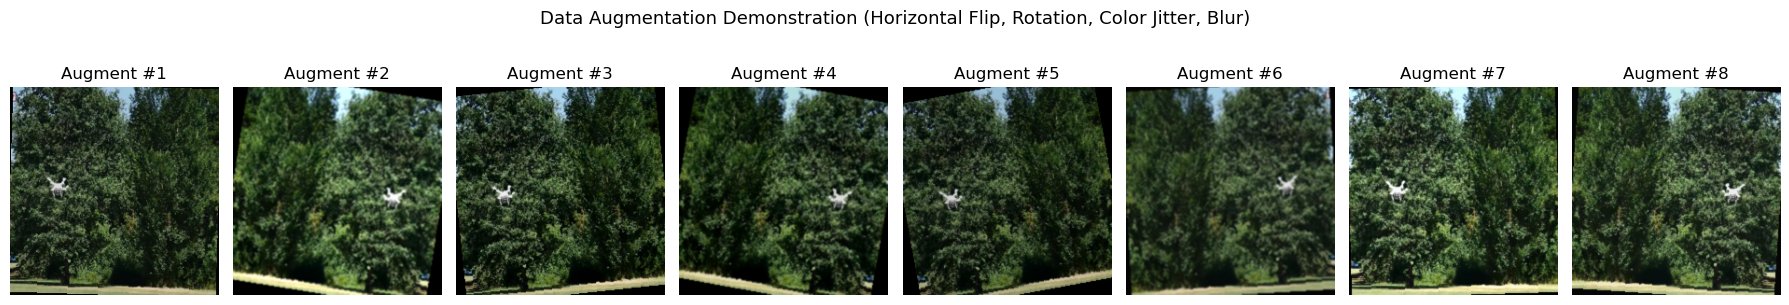

In [11]:
# PyTorch augmentation transform
train_aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
])

# Pick one training drone image
sample_img_path = train_df[train_df['label3'] == 1].iloc[0]['image_path']
orig_img = Image.open(sample_img_path).convert('RGB')

fig, axes = plt.subplots(1, 8, figsize=(18, 3))
for i in range(8):
    aug_img = train_aug_transform(orig_img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augment #{i+1}")
    axes[i].axis('off')

plt.suptitle("Data Augmentation Demonstration (Horizontal Flip, Rotation, Color Jitter, Blur)", fontsize=13, y=1.05)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'image_augmentation_demo.png')
plt.savefig(fig_path, dpi=300)
plt.show()


### Step 12: Save Manifest CSV and Metadata
We save the final manifest table (`image_manifest.csv`) containing image path, source dataset, 3-class label, perceptual hash, and split designation.
We also save class weights for Notebook 04.


In [12]:
# Save manifest
manifest_path = os.path.join(DATA_PROCESSED, 'image_manifest.csv')
columns_to_save = ['image_path', 'source_dataset', 'original_class', 'label3', 'split']
df_dedup[columns_to_save].to_csv(manifest_path, index=False)

# Save class weights
weights_path = os.path.join(MODELS_STORE, 'image_class_weights.joblib')
joblib.dump(class_weights_dict, weights_path)

print(f"Manifest saved to: {manifest_path} ({len(df_dedup)} records)")
print(f"Class weights saved to: {weights_path}")
print("\nFirst 5 rows of saved manifest:")
display(df_dedup[columns_to_save].head())


Manifest saved to: ../data/processed\image_manifest.csv (7372 records)
Class weights saved to: ../models_store\image_class_weights.joblib

First 5 rows of saved manifest:


,image_path,source_dataset,original_class,label3,split
0,C:\Users\athar\OneDrive\Desktop\skyshield_new\...,D1_BirdVsDrone,bird,0,train
1,C:\Users\athar\OneDrive\Desktop\skyshield_new\...,D1_BirdVsDrone,bird,0,val
2,C:\Users\athar\OneDrive\Desktop\skyshield_new\...,D1_BirdVsDrone,bird,0,train
3,C:\Users\athar\OneDrive\Desktop\skyshield_new\...,D1_BirdVsDrone,bird,0,train
4,C:\Users\athar\OneDrive\Desktop\skyshield_new\...,D1_BirdVsDrone,bird,0,train


### Summary and What We Learned
In this notebook, we completed the comprehensive image audit and preprocessing pipeline:
1. **Dataset Unification:** Merged D1 (Bird vs Drone) with selectively sampled bounding-box crops from D3 (AOD-4).
2. **Balanced Image Pool:** Achieved a balanced pool of ~7,500 images:
   - **Bird:** ~2,500
   - **Drone:** ~2,500
   - **Other:** ~2,500 (Airplane & Helicopter)
3. **De-duplication:** Applied perceptual hashing (`imagehash.phash`) to eliminate duplicate images and identical frames.
4. **Stratified Splitting:** Created leak-free 70 / 15 / 15 Train-Val-Test splits stratified by class and source dataset.
5. **Class Weighting & Augmentation:** Fitted class weights purely on the training split and validated robust aerial augmentations.
6. **Artifact Storage:** Manifest saved to `data/processed/image_manifest.csv`, fully prepared for CNN training in Notebook 04.
